<a href="https://colab.research.google.com/github/pietroduke/GeoIdTree/blob/main/Normal_Full_VIT_154.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip /content/drive/MyDrive/dora_dataset/dataset_patches_filtered/VNUF-24082024-154.zip
!unzip /content/drive/MyDrive/dora_dataset/dataset_patches_filtered/VNUF-24082024-299.zip
!unzip /content/drive/MyDrive/dora_dataset/dataset_patches_filtered/VNUF-10082024-234.zip
!unzip /content/drive/MyDrive/dora_dataset/dataset_patches_filtered/VNUF-22052024-134.zip
!unzip /content/drive/MyDrive/dora_dataset/dataset_patches_filtered/VNUF-24082024-154-plus.zip
!unzip /content/drive/MyDrive/dora_dataset/dataset_patches_filtered/VNUF-24082024-299-plus.zip
!unzip /content/drive/MyDrive/dora_dataset/dataset_patches_filtered/VNUF-10082024-234-plus.zip
!unzip /content/drive/MyDrive/dora_dataset/dataset_patches_filtered/VNUF-22052024-134-plus.zip

Streaming output truncated to the last 5000 lines.
  inflating: VNUF-24082024-299/train/Dracontomelon dao/110_patch8.png  
  inflating: VNUF-24082024-299/train/Dracontomelon dao/110_patch9.png  
  inflating: VNUF-24082024-299/train/Dracontomelon dao/147_patch1.png  
  inflating: VNUF-24082024-299/train/Dracontomelon dao/179_patch1.png  
  inflating: VNUF-24082024-299/train/Dracontomelon dao/179_patch2.png  
  inflating: VNUF-24082024-299/train/Dracontomelon dao/179_patch3.png  
  inflating: VNUF-24082024-299/train/Dracontomelon dao/179_patch4.png  
  inflating: VNUF-24082024-299/train/Dracontomelon dao/179_patch5.png  
  inflating: VNUF-24082024-299/train/Dracontomelon dao/17_patch1.png  
  inflating: VNUF-24082024-299/train/Dracontomelon dao/17_patch2.png  
  inflating: VNUF-24082024-299/train/Dracontomelon dao/17_patch3.png  
  inflating: VNUF-24082024-299/train/Dracontomelon dao/17_patch4.png  
  inflating: VNUF-24082024-299/train/Dracontomelon dao/17_patch5.png  
  inflating: VNUF-

### Tạo folder mới và trộn dữ liệu từ `VNUF-24082024-154` và `VNUF-24082024-154-plus`

In [3]:
import os
import shutil

# Define base paths for the source datasets
SOURCE_BASE_DIR_1 = "/content/VNUF-24082024-154"
SOURCE_BASE_DIR_2 = "/content/VNUF-24082024-154-plus"

# Define the destination path for the combined full dataset
DEST_FULL_DIR = "/content/VNUF-24082024-154-full"

print(f"Source dataset 1 base directory: {SOURCE_BASE_DIR_1}")
print(f"Source dataset 2 base directory: {SOURCE_BASE_DIR_2}")
print(f"Destination combined full directory: {DEST_FULL_DIR}")

Source dataset 1 base directory: /content/VNUF-24082024-154
Source dataset 2 base directory: /content/VNUF-24082024-154-plus
Destination combined full directory: /content/VNUF-24082024-154-full


In [4]:
import os
import shutil

# Create the destination combined directory if it doesn't exist
os.makedirs(DEST_FULL_DIR, exist_ok=True)
print(f"Created or ensured existence of: {DEST_FULL_DIR}")

# List of all source root directories to process
all_source_root_dirs = [
    os.path.join(SOURCE_BASE_DIR_1, "train"),
    os.path.join(SOURCE_BASE_DIR_1, "val"),
    os.path.join(SOURCE_BASE_DIR_1, "test"),
    os.path.join(SOURCE_BASE_DIR_2, "train"),
    os.path.join(SOURCE_BASE_DIR_2, "val"),
    os.path.join(SOURCE_BASE_DIR_2, "test")
]

# Iterate through each source root directory (train, val, test for both datasets)
for src_root_dir in all_source_root_dirs:
    if not os.path.exists(src_root_dir):
        print(f"Warning: Source directory not found: {src_root_dir}. Skipping.")
        continue

    # Determine the target subdirectory (train, val, or test)
    dest_subdir_name = os.path.basename(src_root_dir)
    dest_subdir_path = os.path.join(DEST_FULL_DIR, dest_subdir_name)
    os.makedirs(dest_subdir_path, exist_ok=True) # Create train/val/test in DEST_FULL_DIR

    print(f"\nProcessing images from: {src_root_dir} into {dest_subdir_path}")
    # Iterate through each class subfolder in the current source directory
    for class_name in os.listdir(src_root_dir):
        src_class_dir = os.path.join(src_root_dir, class_name)
        # Construct the destination class directory within the correct train/val/test subdirectory
        dest_class_dir = os.path.join(dest_subdir_path, class_name)

        # Create the corresponding class subfolder in the destination mixed directory
        os.makedirs(dest_class_dir, exist_ok=True)

        # Copy all image files from the source class directory to the destination class directory
        for filename in os.listdir(src_class_dir):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
                src_file_path = os.path.join(src_class_dir, filename)
                dest_file_path = os.path.join(dest_class_dir, filename)

                # Handle potential duplicate filenames by appending a suffix
                counter = 1
                original_filename_no_ext, ext = os.path.splitext(filename)
                while os.path.exists(dest_file_path):
                    dest_file_path = os.path.join(dest_class_dir, f"{original_filename_no_ext}_{counter}{ext}")
                    counter += 1

                shutil.copy(src_file_path, dest_file_path)

        print(f"  Copied images for class '{class_name}' to {dest_class_dir}")

print(f"\n✨ Data combination complete. All images are now correctly structured in {DEST_FULL_DIR} folder.")

Created or ensured existence of: /content/VNUF-24082024-154-full

Processing images from: /content/VNUF-24082024-154/train into /content/VNUF-24082024-154-full/train
  Copied images for class 'Cinnamomum parthenoxylon' to /content/VNUF-24082024-154-full/train/Cinnamomum parthenoxylon
  Copied images for class 'Acacia auriculiformis' to /content/VNUF-24082024-154-full/train/Acacia auriculiformis
  Copied images for class 'Ficus benghalensis' to /content/VNUF-24082024-154-full/train/Ficus benghalensis
  Copied images for class 'Pinus massoniana' to /content/VNUF-24082024-154-full/train/Pinus massoniana
  Copied images for class 'Delonix regia' to /content/VNUF-24082024-154-full/train/Delonix regia
  Copied images for class 'Chukrasia tabularis' to /content/VNUF-24082024-154-full/train/Chukrasia tabularis
  Copied images for class 'Alstonia scholaris' to /content/VNUF-24082024-154-full/train/Alstonia scholaris
  Copied images for class 'Aphanamixis grandifolia' to /content/VNUF-24082024-1

### Tạo folder mới và trộn dữ liệu từ `VNUF-24082024-299` và `VNUF-24082024-299-plus`

In [5]:
import os
import shutil

# Define base paths for the source datasets
SOURCE_BASE_DIR_1 = "/content/VNUF-24082024-299"
SOURCE_BASE_DIR_2 = "/content/VNUF-24082024-299-plus"

# Define the destination path for the combined full dataset
DEST_FULL_DIR = "/content/VNUF-24082024-299-full"

# Remove existing directory if it exists to ensure a clean merge
!rm -rf {DEST_FULL_DIR}

print(f"Source dataset 1 base directory: {SOURCE_BASE_DIR_1}")
print(f"Source dataset 2 base directory: {SOURCE_BASE_DIR_2}")
print(f"Destination combined full directory: {DEST_FULL_DIR}")

Source dataset 1 base directory: /content/VNUF-24082024-299
Source dataset 2 base directory: /content/VNUF-24082024-299-plus
Destination combined full directory: /content/VNUF-24082024-299-full


In [6]:
# Create the destination combined directory if it doesn't exist
os.makedirs(DEST_FULL_DIR, exist_ok=True)
print(f"Created or ensured existence of: {DEST_FULL_DIR}")

# List of all source root directories to process
all_source_root_dirs = [
    os.path.join(SOURCE_BASE_DIR_1, "train"),
    os.path.join(SOURCE_BASE_DIR_1, "val"),
    os.path.join(SOURCE_BASE_DIR_1, "test"),
    os.path.join(SOURCE_BASE_DIR_2, "train"),
    os.path.join(SOURCE_BASE_DIR_2, "val"),
    os.path.join(SOURCE_BASE_DIR_2, "test")
]

# Iterate through each source root directory (train, val, test for both datasets)
for src_root_dir in all_source_root_dirs:
    if not os.path.exists(src_root_dir):
        print(f"Warning: Source directory not found: {src_root_dir}. Skipping.")
        continue

    # Determine the target subdirectory (train, val, or test)
    dest_subdir_name = os.path.basename(src_root_dir)
    dest_subdir_path = os.path.join(DEST_FULL_DIR, dest_subdir_name)
    os.makedirs(dest_subdir_path, exist_ok=True) # Create train/val/test in DEST_FULL_DIR

    print(f"\nProcessing images from: {src_root_dir} into {dest_subdir_path}")
    # Iterate through each class subfolder in the current source directory
    for class_name in os.listdir(src_root_dir):
        src_class_dir = os.path.join(src_root_dir, class_name)
        # Construct the destination class directory within the correct train/val/test subdirectory
        dest_class_dir = os.path.join(dest_subdir_path, class_name)

        # Create the corresponding class subfolder in the destination mixed directory
        os.makedirs(dest_class_dir, exist_ok=True)

        # Copy all image files from the source class directory to the destination class directory
        for filename in os.listdir(src_class_dir):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
                src_file_path = os.path.join(src_class_dir, filename)
                dest_file_path = os.path.join(dest_class_dir, filename)

                # Handle potential duplicate filenames by appending a suffix
                counter = 1
                original_filename_no_ext, ext = os.path.splitext(filename)
                while os.path.exists(dest_file_path):
                    dest_file_path = os.path.join(dest_class_dir, f"{original_filename_no_ext}_{counter}{ext}")
                    counter += 1

                shutil.copy(src_file_path, dest_file_path)

        print(f"  Copied images for class '{class_name}' to {dest_class_dir}")

print(f"\n✨ Data combination complete. All images are now correctly structured in {DEST_FULL_DIR} folder.")

Created or ensured existence of: /content/VNUF-24082024-299-full

Processing images from: /content/VNUF-24082024-299/train into /content/VNUF-24082024-299-full/train
  Copied images for class 'Cinnamomum parthenoxylon' to /content/VNUF-24082024-299-full/train/Cinnamomum parthenoxylon
  Copied images for class 'Acacia auriculiformis' to /content/VNUF-24082024-299-full/train/Acacia auriculiformis
  Copied images for class 'Ficus benghalensis' to /content/VNUF-24082024-299-full/train/Ficus benghalensis
  Copied images for class 'Pinus massoniana' to /content/VNUF-24082024-299-full/train/Pinus massoniana
  Copied images for class 'Delonix regia' to /content/VNUF-24082024-299-full/train/Delonix regia
  Copied images for class 'Chukrasia tabularis' to /content/VNUF-24082024-299-full/train/Chukrasia tabularis
  Copied images for class 'Alstonia scholaris' to /content/VNUF-24082024-299-full/train/Alstonia scholaris
  Copied images for class 'Aphanamixis grandifolia' to /content/VNUF-24082024-2

### Tạo folder mới và trộn dữ liệu từ `VNUF-10082024-234` và `VNUF-10082024-234-plus`

In [7]:
import os
import shutil

# Define base paths for the source datasets
SOURCE_BASE_DIR_1 = "/content/VNUF-10082024-234"
SOURCE_BASE_DIR_2 = "/content/VNUF-10082024-234-plus"

# Define the destination path for the combined full dataset
DEST_FULL_DIR = "/content/VNUF-10082024-234-full"

# Remove existing directory if it exists to ensure a clean merge
!rm -rf {DEST_FULL_DIR}

print(f"Source dataset 1 base directory: {SOURCE_BASE_DIR_1}")
print(f"Source dataset 2 base directory: {SOURCE_BASE_DIR_2}")
print(f"Destination combined full directory: {DEST_FULL_DIR}")

Source dataset 1 base directory: /content/VNUF-10082024-234
Source dataset 2 base directory: /content/VNUF-10082024-234-plus
Destination combined full directory: /content/VNUF-10082024-234-full


In [8]:
# Create the destination combined directory if it doesn't exist
os.makedirs(DEST_FULL_DIR, exist_ok=True)
print(f"Created or ensured existence of: {DEST_FULL_DIR}")

# List of all source root directories to process
all_source_root_dirs = [
    os.path.join(SOURCE_BASE_DIR_1, "train"),
    os.path.join(SOURCE_BASE_DIR_1, "val"),
    os.path.join(SOURCE_BASE_DIR_1, "test"),
    os.path.join(SOURCE_BASE_DIR_2, "train"),
    os.path.join(SOURCE_BASE_DIR_2, "val"),
    os.path.join(SOURCE_BASE_DIR_2, "test")
]

# Iterate through each source root directory (train, val, test for both datasets)
for src_root_dir in all_source_root_dirs:
    if not os.path.exists(src_root_dir):
        print(f"Warning: Source directory not found: {src_root_dir}. Skipping.")
        continue

    # Determine the target subdirectory (train, val, or test)
    dest_subdir_name = os.path.basename(src_root_dir)
    dest_subdir_path = os.path.join(DEST_FULL_DIR, dest_subdir_name)
    os.makedirs(dest_subdir_path, exist_ok=True) # Create train/val/test in DEST_FULL_DIR

    print(f"\nProcessing images from: {src_root_dir} into {dest_subdir_path}")
    # Iterate through each class subfolder in the current source directory
    for class_name in os.listdir(src_root_dir):
        src_class_dir = os.path.join(src_root_dir, class_name)
        # Construct the destination class directory within the correct train/val/test subdirectory
        dest_class_dir = os.path.join(dest_subdir_path, class_name)

        # Create the corresponding class subfolder in the destination mixed directory
        os.makedirs(dest_class_dir, exist_ok=True)

        # Copy all image files from the source class directory to the destination class directory
        for filename in os.listdir(src_class_dir):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
                src_file_path = os.path.join(src_class_dir, filename)
                dest_file_path = os.path.join(dest_class_dir, filename)

                # Handle potential duplicate filenames by appending a suffix
                counter = 1
                original_filename_no_ext, ext = os.path.splitext(filename)
                while os.path.exists(dest_file_path):
                    dest_file_path = os.path.join(dest_class_dir, f"{original_filename_no_ext}_{counter}{ext}")
                    counter += 1

                shutil.copy(src_file_path, dest_file_path)

        print(f"  Copied images for class '{class_name}' to {dest_class_dir}")

print(f"\n✨ Data combination complete. All images are now correctly structured in {DEST_FULL_DIR} folder.")

Created or ensured existence of: /content/VNUF-10082024-234-full

Processing images from: /content/VNUF-10082024-234/train into /content/VNUF-10082024-234-full/train
  Copied images for class 'Cinnamomum parthenoxylon' to /content/VNUF-10082024-234-full/train/Cinnamomum parthenoxylon
  Copied images for class 'Acacia auriculiformis' to /content/VNUF-10082024-234-full/train/Acacia auriculiformis
  Copied images for class 'Ficus benghalensis' to /content/VNUF-10082024-234-full/train/Ficus benghalensis
  Copied images for class 'Pinus massoniana' to /content/VNUF-10082024-234-full/train/Pinus massoniana
  Copied images for class 'Delonix regia' to /content/VNUF-10082024-234-full/train/Delonix regia
  Copied images for class 'Chukrasia tabularis' to /content/VNUF-10082024-234-full/train/Chukrasia tabularis
  Copied images for class 'Alstonia scholaris' to /content/VNUF-10082024-234-full/train/Alstonia scholaris
  Copied images for class 'Aphanamixis grandifolia' to /content/VNUF-10082024-2

### Tạo folder mới và trộn dữ liệu từ `VNUF-22052024-134` và `VNUF-22052024-134-plus`

In [9]:
import os
import shutil

# Define base paths for the source datasets
SOURCE_BASE_DIR_1 = "/content/VNUF-22052024-134"
SOURCE_BASE_DIR_2 = "/content/VNUF-22052024-134-plus"

# Define the destination path for the combined full dataset
DEST_FULL_DIR = "/content/VNUF-22052024-134-full"

# Remove existing directory if it exists to ensure a clean merge
!rm -rf {DEST_FULL_DIR}

print(f"Source dataset 1 base directory: {SOURCE_BASE_DIR_1}")
print(f"Source dataset 2 base directory: {SOURCE_BASE_DIR_2}")
print(f"Destination combined full directory: {DEST_FULL_DIR}")

Source dataset 1 base directory: /content/VNUF-22052024-134
Source dataset 2 base directory: /content/VNUF-22052024-134-plus
Destination combined full directory: /content/VNUF-22052024-134-full


In [10]:
# Create the destination combined directory if it doesn't exist
os.makedirs(DEST_FULL_DIR, exist_ok=True)
print(f"Created or ensured existence of: {DEST_FULL_DIR}")

# List of all source root directories to process
all_source_root_dirs = [
    os.path.join(SOURCE_BASE_DIR_1, "train"),
    os.path.join(SOURCE_BASE_DIR_1, "val"),
    os.path.join(SOURCE_BASE_DIR_1, "test"),
    os.path.join(SOURCE_BASE_DIR_2, "train"),
    os.path.join(SOURCE_BASE_DIR_2, "val"),
    os.path.join(SOURCE_BASE_DIR_2, "test")
]

# Iterate through each source root directory (train, val, test for both datasets)
for src_root_dir in all_source_root_dirs:
    if not os.path.exists(src_root_dir):
        print(f"Warning: Source directory not found: {src_root_dir}. Skipping.")
        continue

    # Determine the target subdirectory (train, val, or test)
    dest_subdir_name = os.path.basename(src_root_dir)
    dest_subdir_path = os.path.join(DEST_FULL_DIR, dest_subdir_name)
    os.makedirs(dest_subdir_path, exist_ok=True) # Create train/val/test in DEST_FULL_DIR

    print(f"\nProcessing images from: {src_root_dir} into {dest_subdir_path}")
    # Iterate through each class subfolder in the current source directory
    for class_name in os.listdir(src_root_dir):
        src_class_dir = os.path.join(src_root_dir, class_name)
        # Construct the destination class directory within the correct train/val/test subdirectory
        dest_class_dir = os.path.join(dest_subdir_path, class_name)

        # Create the corresponding class subfolder in the destination mixed directory
        os.makedirs(dest_class_dir, exist_ok=True)

        # Copy all image files from the source class directory to the destination class directory
        for filename in os.listdir(src_class_dir):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
                src_file_path = os.path.join(src_class_dir, filename)
                dest_file_path = os.path.join(dest_class_dir, filename)

                # Handle potential duplicate filenames by appending a suffix
                counter = 1
                original_filename_no_ext, ext = os.path.splitext(filename)
                while os.path.exists(dest_file_path):
                    dest_file_path = os.path.join(dest_class_dir, f"{original_filename_no_ext}_{counter}{ext}")
                    counter += 1

                shutil.copy(src_file_path, dest_file_path)

        print(f"  Copied images for class '{class_name}' to {dest_class_dir}")

print(f"\n✨ Data combination complete. All images are now correctly structured in {DEST_FULL_DIR} folder.")

Created or ensured existence of: /content/VNUF-22052024-134-full

Processing images from: /content/VNUF-22052024-134/train into /content/VNUF-22052024-134-full/train
  Copied images for class 'Cinnamomum parthenoxylon' to /content/VNUF-22052024-134-full/train/Cinnamomum parthenoxylon
  Copied images for class 'Acacia auriculiformis' to /content/VNUF-22052024-134-full/train/Acacia auriculiformis
  Copied images for class 'Ficus benghalensis' to /content/VNUF-22052024-134-full/train/Ficus benghalensis
  Copied images for class 'Pinus massoniana' to /content/VNUF-22052024-134-full/train/Pinus massoniana
  Copied images for class 'Delonix regia' to /content/VNUF-22052024-134-full/train/Delonix regia
  Copied images for class 'Chukrasia tabularis' to /content/VNUF-22052024-134-full/train/Chukrasia tabularis
  Copied images for class 'Alstonia scholaris' to /content/VNUF-22052024-134-full/train/Alstonia scholaris
  Copied images for class 'Aphanamixis grandifolia' to /content/VNUF-22052024-1

### Tạo folder mới và trộn dữ liệu (For MIX)

In [ ]:
# import os
# import shutil

# # Define source directories to be mixed
# SOURCE_DIR_1 = "/content/VNUF-24082024-154/val"
# SOURCE_DIR_2 = "/content/VNUF-10082024-234/val"

# # Define the destination path for the mixed dataset
# DEST_MIXED_TRAIN_DIR = "/content/VNUF-082024/val"

# print(f"Source directory 1: {SOURCE_DIR_1}")
# print(f"Source directory 2: {SOURCE_DIR_2}")
# print(f"Destination mixed train directory: {DEST_MIXED_TRAIN_DIR}")

Source directory 1: /content/VNUF-24082024-154/val
Source directory 2: /content/VNUF-10082024-234/val
Destination mixed train directory: /content/VNUF-082024/val


In [ ]:
# # Create the destination mixed directory if it doesn't exist
# os.makedirs(DEST_MIXED_TRAIN_DIR, exist_ok=True)
# print(f"Created or ensured existence of: {DEST_MIXED_TRAIN_DIR}")

# # List of source directories to combine
# source_dirs_to_mix = [SOURCE_DIR_1, SOURCE_DIR_2]

# # Iterate through each source directory
# for src_root_dir in source_dirs_to_mix:
#     if not os.path.exists(src_root_dir):
#         print(f"Warning: Source directory not found: {src_root_dir}. Skipping.")
#         continue

#     print(f"\nProcessing images from: {src_root_dir}")
#     # Iterate through each class subfolder in the current source directory
#     for class_name in os.listdir(src_root_dir):
#         src_class_dir = os.path.join(src_root_dir, class_name)
#         dest_class_dir = os.path.join(DEST_MIXED_TRAIN_DIR, class_name)

#         # Create the corresponding class subfolder in the destination mixed directory
#         os.makedirs(dest_class_dir, exist_ok=True)

#         # Copy all image files from the source class directory to the destination class directory
#         for filename in os.listdir(src_class_dir):
#             if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
#                 src_file_path = os.path.join(src_class_dir, filename)
#                 dest_file_path = os.path.join(dest_class_dir, filename)

#                 # Handle potential duplicate filenames by appending a suffix
#                 counter = 1
#                 original_filename_no_ext, ext = os.path.splitext(filename)
#                 while os.path.exists(dest_file_path):
#                     dest_file_path = os.path.join(dest_class_dir, f"{original_filename_no_ext}_{counter}{ext}")
#                     counter += 1

#                 shutil.copy(src_file_path, dest_file_path)

#         print(f"  Copied images for class '{class_name}' to {dest_class_dir}")

# print("\n✨ Data mixing complete. All images are now in the VNUF-082024/train folder.")

Created or ensured existence of: /content/VNUF-082024/val

Processing images from: /content/VNUF-24082024-154/val
  Copied images for class 'Cinnamomum parthenoxylon' to /content/VNUF-082024/val/Cinnamomum parthenoxylon
  Copied images for class 'Acacia auriculiformis' to /content/VNUF-082024/val/Acacia auriculiformis
  Copied images for class 'Ficus benghalensis' to /content/VNUF-082024/val/Ficus benghalensis
  Copied images for class 'Pinus massoniana' to /content/VNUF-082024/val/Pinus massoniana
  Copied images for class 'Delonix regia' to /content/VNUF-082024/val/Delonix regia
  Copied images for class 'Chukrasia tabularis' to /content/VNUF-082024/val/Chukrasia tabularis
  Copied images for class 'Alstonia scholaris' to /content/VNUF-082024/val/Alstonia scholaris
  Copied images for class 'Aphanamixis grandifolia' to /content/VNUF-082024/val/Aphanamixis grandifolia
  Copied images for class 'Dracontomelon dao' to /content/VNUF-082024/val/Dracontomelon dao
  Copied images for class 

### Mix bộ VNUF-24082024-299 và bộ VNUF-22052024-134

In [27]:
!rm -rf /content/VNUF-24082024-299-mix
!rm -rf /content/VNUF-22052024-134-mix

In [28]:
import os
import shutil

# Define base paths for the source dataset
SOURCE_BASE_DIR = "/content/VNUF-22052024-134-full"
SOURCE_TRAIN_DIR = os.path.join(SOURCE_BASE_DIR, "train")
SOURCE_VAL_DIR = os.path.join(SOURCE_BASE_DIR, "val")
SOURCE_TEST_DIR = os.path.join(SOURCE_BASE_DIR, "test")

# Define the destination path for the mixed dataset
DEST_MIX_DIR = "/content/VNUF-22052024-134-mix"

print(f"Source dataset base directory: {SOURCE_BASE_DIR}")
print(f"Destination mixed directory: {DEST_MIX_DIR}")

Source dataset base directory: /content/VNUF-22052024-134-full
Destination mixed directory: /content/VNUF-22052024-134-mix


In [29]:
# Create the destination mixed directory if it doesn't exist
os.makedirs(DEST_MIX_DIR, exist_ok=True)
print(f"Created or ensured existence of: {DEST_MIX_DIR}")

# List of source directories to combine
source_dirs = [SOURCE_TRAIN_DIR, SOURCE_VAL_DIR, SOURCE_TEST_DIR]

# Iterate through each source directory (train, val, test)
for src_root_dir in source_dirs:
    if not os.path.exists(src_root_dir):
        print(f"Warning: Source directory not found: {src_root_dir}. Skipping.")
        continue

    print(f"\nProcessing images from: {src_root_dir}")
    # Iterate through each class subfolder in the current source directory
    for class_name in os.listdir(src_root_dir):
        src_class_dir = os.path.join(src_root_dir, class_name)
        dest_class_dir = os.path.join(DEST_MIX_DIR, class_name)

        # Create the corresponding class subfolder in the destination mixed directory
        os.makedirs(dest_class_dir, exist_ok=True)

        # Copy all image files from the source class directory to the destination class directory
        for filename in os.listdir(src_class_dir):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
                src_file_path = os.path.join(src_class_dir, filename)
                dest_file_path = os.path.join(dest_class_dir, filename)

                # Handle potential duplicate filenames by appending a suffix
                counter = 1
                original_filename_no_ext, ext = os.path.splitext(filename)
                while os.path.exists(dest_file_path):
                    dest_file_path = os.path.join(dest_class_dir, f"{original_filename_no_ext}_{counter}{ext}")
                    counter += 1

                shutil.copy(src_file_path, dest_file_path)

        print(f"  Copied images for class '{class_name}' to {dest_class_dir}")

print("\n✨ Data mixing complete. All images are now in the VNUF-24082024-299-mix folder.")

Created or ensured existence of: /content/VNUF-22052024-134-mix

Processing images from: /content/VNUF-22052024-134-full/train
  Copied images for class 'Cinnamomum parthenoxylon' to /content/VNUF-22052024-134-mix/Cinnamomum parthenoxylon
  Copied images for class 'Acacia auriculiformis' to /content/VNUF-22052024-134-mix/Acacia auriculiformis
  Copied images for class 'Alangium chinense' to /content/VNUF-22052024-134-mix/Alangium chinense
  Copied images for class 'Peltophorum pterocarpum' to /content/VNUF-22052024-134-mix/Peltophorum pterocarpum
  Copied images for class 'Quercus platycalyx' to /content/VNUF-22052024-134-mix/Quercus platycalyx
  Copied images for class 'Castanopsis cerebrina' to /content/VNUF-22052024-134-mix/Castanopsis cerebrina
  Copied images for class 'Pterospermum heterophyllum' to /content/VNUF-22052024-134-mix/Pterospermum heterophyllum
  Copied images for class 'Lithocarpus pseudosundaicus' to /content/VNUF-22052024-134-mix/Lithocarpus pseudosundaicus
  Copie

In [30]:
import os
import shutil

# Define base paths for the source dataset
SOURCE_BASE_DIR = "/content/VNUF-24082024-299-full"
SOURCE_TRAIN_DIR = os.path.join(SOURCE_BASE_DIR, "train")
SOURCE_VAL_DIR = os.path.join(SOURCE_BASE_DIR, "val")
SOURCE_TEST_DIR = os.path.join(SOURCE_BASE_DIR, "test")

# Define the destination path for the mixed dataset
DEST_MIX_DIR = "/content/VNUF-24082024-299-mix"

print(f"Source dataset base directory: {SOURCE_BASE_DIR}")
print(f"Destination mixed directory: {DEST_MIX_DIR}")

Source dataset base directory: /content/VNUF-24082024-299-full
Destination mixed directory: /content/VNUF-24082024-299-mix


In [31]:
# Create the destination mixed directory if it doesn't exist
os.makedirs(DEST_MIX_DIR, exist_ok=True)
print(f"Created or ensured existence of: {DEST_MIX_DIR}")

# List of source directories to combine
source_dirs = [SOURCE_TRAIN_DIR, SOURCE_VAL_DIR, SOURCE_TEST_DIR]

# Iterate through each source directory (train, val, test)
for src_root_dir in source_dirs:
    if not os.path.exists(src_root_dir):
        print(f"Warning: Source directory not found: {src_root_dir}. Skipping.")
        continue

    print(f"\nProcessing images from: {src_root_dir}")
    # Iterate through each class subfolder in the current source directory
    for class_name in os.listdir(src_root_dir):
        src_class_dir = os.path.join(src_root_dir, class_name)
        dest_class_dir = os.path.join(DEST_MIX_DIR, class_name)

        # Create the corresponding class subfolder in the destination mixed directory
        os.makedirs(dest_class_dir, exist_ok=True)

        # Copy all image files from the source class directory to the destination class directory
        for filename in os.listdir(src_class_dir):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
                src_file_path = os.path.join(src_class_dir, filename)
                dest_file_path = os.path.join(dest_class_dir, filename)

                # Handle potential duplicate filenames by appending a suffix
                counter = 1
                original_filename_no_ext, ext = os.path.splitext(filename)
                while os.path.exists(dest_file_path):
                    dest_file_path = os.path.join(dest_class_dir, f"{original_filename_no_ext}_{counter}{ext}")
                    counter += 1

                shutil.copy(src_file_path, dest_file_path)

        print(f"  Copied images for class '{class_name}' to {dest_class_dir}")

print("\n✨ Data mixing complete. All images are now in the VNUF-24082024-299-mix folder.")

Created or ensured existence of: /content/VNUF-24082024-299-mix

Processing images from: /content/VNUF-24082024-299-full/train
  Copied images for class 'Cinnamomum parthenoxylon' to /content/VNUF-24082024-299-mix/Cinnamomum parthenoxylon
  Copied images for class 'Acacia auriculiformis' to /content/VNUF-24082024-299-mix/Acacia auriculiformis
  Copied images for class 'Alangium chinense' to /content/VNUF-24082024-299-mix/Alangium chinense
  Copied images for class 'Peltophorum pterocarpum' to /content/VNUF-24082024-299-mix/Peltophorum pterocarpum
  Copied images for class 'Quercus platycalyx' to /content/VNUF-24082024-299-mix/Quercus platycalyx
  Copied images for class 'Castanopsis cerebrina' to /content/VNUF-24082024-299-mix/Castanopsis cerebrina
  Copied images for class 'Pterospermum heterophyllum' to /content/VNUF-24082024-299-mix/Pterospermum heterophyllum
  Copied images for class 'Lithocarpus pseudosundaicus' to /content/VNUF-24082024-299-mix/Lithocarpus pseudosundaicus
  Copie

# Methodology

In [15]:
# ============================================================
# CORAL Domain Adaptation — vit_base_patch16_224
# Source domain: VNUF-24082024-154 (labeled)
# Target domain: VNUF-24082024-299 / 234 / 134 (unlabeled)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import torch.nn.functional as F
import timm # Import timm library

# ─────────────────────────────────────────
# 1. CORAL LOSS — Correlation Alignment (Sun & Saenko, 2016)
# ─────────────────────────────────────────
class CORALDomainAdaptationLoss(nn.Module):
    """
    CORAL Loss — Correlation Alignment (Sun & Saenko, 2016).
    L_CORAL = (1 / 4d²) * ||C_S - C_T||²_F
    """
    def __init__(self, reduction: str = "mean"):
        super().__init__()
        assert reduction in ("mean", "sum")
        self.reduction = reduction

    @staticmethod
    def _covariance(features: torch.Tensor) -> torch.Tensor:
        """Unbiased covariance matrix (D, D). Guard cho n=1."""
        n = features.size(0)
        if n <= 1:
            d = features.size(1)
            return torch.zeros(d, d, device=features.device, dtype=features.dtype)
        features = features.float()          # AMP safety
        centered = features - features.mean(dim=0, keepdim=True)
        return (centered.T @ centered) / (n - 1)

    def forward(self, source: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        d = source.size(1)
        cov_s = self._covariance(source)
        cov_t = self._covariance(target)
        diff = cov_s - cov_t
        loss = (diff * diff).sum()
        if self.reduction == "mean":
            loss = loss / (4.0 * d * d)
        return loss


# ─────────────────────────────────────────
# 2. TRIPLET LOSS
# ─────────────────────────────────────────
class TripletLoss(nn.Module):
    """
    Triplet Loss for metric learning. Implements batch-hard mining.
    """
    def __init__(self, margin: float = 1.0):
        super().__init__()
        self.margin = margin

    def forward(self, features: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        if features.numel() == 0 or labels.numel() == 0: # Handle empty batches gracefully
            return torch.zeros(1, device=features.device)

        # Calculate pairwise squared Euclidean distances
        # (a-b)^2 = a^2 - 2ab + b^2
        dot_product = features @ features.T
        square_norm = torch.diag(dot_product)
        dist_matrix = square_norm.unsqueeze(0) - 2 * dot_product + square_norm.unsqueeze(1)
        dist_matrix = torch.sqrt(torch.relu(dist_matrix)) # Ensure non-negative and take sqrt

        loss = 0.0
        n = features.size(0)

        for i in range(n):
            anchor_label = labels[i]

            # Find positive samples (same label as anchor) excluding anchor itself
            positive_mask = (labels == anchor_label) & (torch.arange(n, device=labels.device) != i)

            # Find negative samples (different label from anchor)
            negative_mask = (labels != anchor_label)

            if not positive_mask.any() or not negative_mask.any():
                continue # Cannot form a triplet if no positives or negatives

            # Hardest positive: largest distance to anchor among positives
            hard_positive_dist = dist_matrix[i, positive_mask].max()

            # Hardest negative: smallest distance to anchor among negatives
            hard_negative_dist = dist_matrix[i, negative_mask].min()

            # Triplet loss formula
            loss += F.relu(hard_positive_dist - hard_negative_dist + self.margin)

        if n > 0:
            return loss / n
        else:
            return torch.zeros(1, device=features.device)


# ─────────────────────────────────────────
# 3. CENTER LOSS
# ─────────────────────────────────────────
class CenterLoss(nn.Module):
    """
    Center Loss for feature learning.
    Penalizes the distance between features and their corresponding class centers.
    """
    def __init__(self, num_classes: int, feat_dim: int, device: torch.device):
        super().__init__()
        self.num_classes = num_classes
        self.feat_dim = feat_dim
        self.device = device
        # Initialize centers randomly or with zeros
        self.centers = nn.Parameter(torch.randn(num_classes, feat_dim).to(device), requires_grad=False)

    def forward(self, features: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        if features.numel() == 0 or labels.numel() == 0: # Handle empty batches gracefully
            return torch.zeros(1, device=features.device)

        batch_size = features.size(0)
        # Select centers corresponding to batch labels
        batch_centers = self.centers.index_select(0, labels)
        # Calculate squared Euclidean distance
        loss = torch.sum(torch.pow(features - batch_centers, 2)) / 2.0
        return loss / batch_size

    def update_centers(self, features: torch.Tensor, labels: torch.Tensor, alpha: float):
        # Update centers for each class in the batch
        for i in range(self.num_classes):
            mask = (labels == i)
            if mask.any():
                # Move centers towards the mean of features for that class
                self.centers.data[i] -= alpha * (self.centers.data[i] - features[mask].mean(dim=0))

# ─────────────────────────────────────────
# 4. FOCAL LOSS
# ─────────────────────────────────────────
class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance"""
    def __init__(self, alpha=1, gamma=2, reduction='mean', num_classes=None):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction

        if isinstance(alpha, (list, np.ndarray)):
            self.alpha = torch.tensor(alpha, dtype=torch.float)
            if num_classes is not None and len(self.alpha) != num_classes:
                raise ValueError(f"Length of alpha tensor ({len(self.alpha)}) must match num_classes ({num_classes})")
        else:
            # If alpha is a scalar, it will be applied uniformly.
            self.alpha = alpha

    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)

        if isinstance(self.alpha, torch.Tensor):
            # Ensure alpha is on the same device as inputs
            if self.alpha.device != inputs.device:
                self.alpha = self.alpha.to(inputs.device)
            # Apply per-class alpha weighting by gathering relevant alpha for each target
            alpha_factor = self.alpha.gather(0, targets.view(-1))
        else:
            # Scalar alpha
            alpha_factor = self.alpha

        focal_loss = alpha_factor * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


In [16]:
class ModelCoral(nn.Module):
    """
    vit_base_patch16_224 backbone + classifier head.
    forward() trả về (logits) để tính Focal loss.
    """
    def __init__(self, num_classes: int, pretrained: bool = True):
        super().__init__()
        # Load vit_base_patch16_224 from timm, removing the default classifier head
        self.base_model = timm.create_model('vit_base_patch16_224', pretrained=pretrained, num_classes=0)

        # The num_features attribute from timm model will give the size after global pooling
        # For vit_base_patch16_224, this is 1024
        model_output_features = self.base_model.num_features

        # Bottleneck nhỏ để giảm chiều trước CORAL
        self.bottleneck = nn.Sequential(
            nn.Linear(model_output_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x: torch.Tensor):
        # Use the base_model to get features before the classifier head
        # When num_classes=0, forward() typically returns features after global pooling
        pooled_features = self.base_model(x)  # (B, 1024)

        # If for some reason the output is not flat (e.g., (B, 1024, 1, 1)), flatten it
        if pooled_features.ndim > 2:
            pooled_features = pooled_features.flatten(1)

        feat     = self.bottleneck(pooled_features)      # (B, 256)
        logits   = self.classifier(feat)        # (B, C)
        return logits

In [17]:
# ─────────────────────────────────────────
# 3. DATA TRANSFORMS
# ─────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [18]:
# ─────────────────────────────────────────
# 4. DATASET & DATALOADER
# ─────────────────────────────────────────
SOURCE_DIR = "/content/VNUF-24082024-154-full/train"   # labeled
# TARGET_DIR = "/content/VNUF-10082024-234/train"   # unlabeled (chỉ cần ảnh)
VAL_DIR    = "/content/VNUF-24082024-154-full/val"

source_dataset = datasets.ImageFolder(SOURCE_DIR, transform=train_transform)
# target_dataset = datasets.ImageFolder(TARGET_DIR, transform=train_transform)
val_dataset    = datasets.ImageFolder(VAL_DIR,    transform=val_transform)

NUM_CLASSES = len(source_dataset.classes)
print(f"Số lớp: {NUM_CLASSES} — {source_dataset.classes}")

source_loader = DataLoader(source_dataset, batch_size=32, shuffle=True,
                           num_workers=4, pin_memory=True, drop_last=True)
# target_loader = DataLoader(target_dataset, batch_size=32, shuffle=True,
                        #    num_workers=4, pin_memory=True, drop_last=True)
val_loader    = DataLoader(val_dataset,    batch_size=32, shuffle=False,
                           num_workers=4, pin_memory=True)




Số lớp: 20 — ['Acacia auriculiformis', 'Alangium chinense', 'Alstonia scholaris', 'Aphanamixis grandifolia', 'Castanopsis cerebrina', 'Chukrasia tabularis', 'Cinnamomum parthenoxylon', 'Cryptocarya lenticellata', 'Delonix regia', 'Dracontomelon dao', 'Ficus auriculata', 'Ficus benghalensis', 'Grewia paniculata', 'Lagerstroemia speciosa', 'Lithocarpus pseudosundaicus', 'Litsea glutinosa', 'Peltophorum pterocarpum', 'Pinus massoniana', 'Pterospermum heterophyllum', 'Quercus platycalyx']


In [21]:
# import os

# root_dir = "/content/VNUF-24082024-154-full/train"  # Thay đổi đường dẫn nếu cần


# image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

# # Get and sort the list of subdirectories (class names)
# sorted_subdirs = sorted(os.listdir(root_dir))

# for subdir in sorted_subdirs:
#     subdir_path = os.path.join(root_dir, subdir)

#     if os.path.isdir(subdir_path):
#         count = sum(
#             1 for file in os.listdir(subdir_path)
#             if file.lower().endswith(image_extensions)
#         )
#         print(f"{subdir}: {count} ảnh")

In [20]:
import numpy as np

samples_per_class = [4225, 31, 104, 2215, 41, 1577, 2669, 30, 963, 1668, 42, 266, 20, 167, 32, 42, 74, 3039, 29, 23] # Ví dụ 11 lớp
total_samples = sum(samples_per_class)

# Cách 1: Nghịch đảo đơn giản
weights = [total_samples / s for s in samples_per_class]

# Cách 2: Chuẩn hóa để tổng hoặc trung bình bằng 1 (ổn định hơn)
weights = np.array(weights)
weights = weights / weights.sum() * 21 # Nhân với số lớp

print(f"Bảng alpha nên set: {weights}")

Bảng alpha nên set: [0.01491041 2.03214446 0.60573537 0.02844085 1.53649947 0.03994704
 0.02360303 2.09988261 0.0654169  0.03776767 1.49991615 0.23682887
 3.14982391 0.37722442 1.96863994 1.49991615 0.85130376 0.02072934
 2.17229235 2.73897731]


In [22]:
# ─────────────────────────────────────────
# 5. TRAINING CONFIG
# ─────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS      = 50
LR          = 1e-5

# Focal Loss parameters
# FOCAL_ALPHA = [0.10095363, 4.10124111, 0.37089485, 0.27046866, 0.15980857, 0.442917, 0.25571288, 1.60349277, 2.55406632, 0.14044421]      # Alpha parameter for Focal Loss
FOCAL_ALPHA = [0.01491041, 2.03214446, 0.60573537, 0.02844085, 1.53649947, 0.03994704
, 0.02360303, 2.09988261, 0.0654169, 0.03776767, 1.49991615, 0.23682887
, 3.14982391, 0.37722442, 1.96863994, 1.49991615, 0.85130376, 0.02072934
, 2.17229235, 2.73897731]
FOCAL_GAMMA = 2      # Gamma parameter for Focal Loss

model      = ModelCoral(num_classes=NUM_CLASSES).to(DEVICE)
focal_loss = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA, num_classes=NUM_CLASSES).to(DEVICE) # Use Focal Loss

optimizer  = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler     = torch.cuda.amp.GradScaler()   # mixed precision

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/tmp/ipykernel_788/815113792.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler     = torch.cuda.amp.GradScaler()   # mixed precision


In [23]:
# ─────────────────────────────────────────
# 6. TRAINING LOOP
# ─────────────────────────────────────────
from tqdm import tqdm # Import tqdm

def train_one_epoch(epoch: int) -> dict:
    model.train()

    total_cls = total_loss = correct = n = 0

    # Wrap source_loader with tqdm for a progress bar
    pbar = tqdm(source_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for src_imgs, src_labels in pbar:

        src_imgs   = src_imgs.to(DEVICE)
        src_labels = src_labels.to(DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            # Forward source → classification
            src_logits = model(src_imgs)
            loss_cls = focal_loss(src_logits, src_labels) # Use Focal Loss for classification

            # Total loss is just Focal Loss
            loss = loss_cls

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Thống kê
        bs = src_imgs.size(0)
        total_cls   += loss_cls.item()   * bs
        total_loss  += loss.item()       * bs
        correct     += (src_logits.argmax(1) == src_labels).sum().item()
        n           += bs

        # Update tqdm progress bar description
        pbar.set_postfix({
            'L_cls': f'{loss_cls.item():.4f}',
            'L_total': f'{loss.item():.4f}',
            'Acc_src': f'{(correct/n)*100:.1f}%'
        })

    scheduler.step()
    return {
        "loss_cls":   total_cls   / n,
        "loss_total": total_loss  / n,
        "acc_src":    correct     / n,
    }


@torch.no_grad()
def evaluate(loader: DataLoader) -> dict:
    model.eval()
    correct = n = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        correct += (logits.argmax(1) == labels).sum().item()
        n       += imgs.size(0)
    return {"acc": correct / n}

In [24]:
# ─────────────────────────────────────────
# 7. MAIN LOOP
# ─────────────────────────────────────────
best_val_acc = 0.0

# Initialize lists to store history
all_train_losses = []
all_train_accs = []
all_val_accs = []

for epoch in range(1, EPOCHS + 1):
    train_stats = train_one_epoch(epoch)
    val_stats   = evaluate(val_loader)

    # Store current epoch's stats
    all_train_losses.append(train_stats['loss_total'])
    all_train_accs.append(train_stats['acc_src'])
    all_val_accs.append(val_stats['acc'])

    print(
        f"Epoch {epoch:3d}/{EPOCHS} | "
        f"L_cls={train_stats['loss_cls']:.4f}  "
        f"L_total={train_stats['loss_total']:.4f} | "
        f"Acc_src={train_stats['acc_src']*100:.1f}%  "
        f"Acc_val={val_stats['acc']*100:.1f}%"
    )

    # Lưu checkpoint tốt nhất
    if val_stats["acc"] > best_val_acc:
        best_val_acc = val_stats["acc"]
        torch.save({
            "epoch":      epoch,
            "model":      model.state_dict(),
            "optimizer":  optimizer.state_dict(),
            "val_acc":    best_val_acc,
        }, "/content/drive/MyDrive/cvbmc/model_chkpoint/1904/NONE_VNUF154_21species_best_vit_base_patch16_224.pth")
        print(f"   ✅ Saved best model — val_acc={best_val_acc*100:.1f}%")

print(f"\nBest val acc: {best_val_acc*100:.2f}%")


Epoch 1/50:   0%|          | 0/539 [00:00<?, ?it/s]/tmp/ipykernel_788/458231136.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/50: 100%|██████████| 539/539 [00:31<00:00, 17.29it/s, L_cls=0.0158, L_total=0.0158, Acc_src=77.7%]


Epoch   1/50 | L_cls=0.0550  L_total=0.0550 | Acc_src=77.7%  Acc_val=71.2%
   ✅ Saved best model — val_acc=71.2%


Epoch 2/50: 100%|██████████| 539/539 [00:30<00:00, 17.66it/s, L_cls=0.0094, L_total=0.0094, Acc_src=87.9%]


Epoch   2/50 | L_cls=0.0137  L_total=0.0137 | Acc_src=87.9%  Acc_val=74.4%
   ✅ Saved best model — val_acc=74.4%


Epoch 3/50: 100%|██████████| 539/539 [00:30<00:00, 17.84it/s, L_cls=0.0190, L_total=0.0190, Acc_src=90.3%]


...

Epoch  31/50 | L_cls=0.0006  L_total=0.0006 | Acc_src=98.5%  Acc_val=80.8%


Epoch 32/50: 100%|██████████| 539/539 [00:29<00:00, 18.37it/s, L_cls=0.0002, L_total=0.0002, Acc_src=98.1%]


Epoch  32/50 | L_cls=0.0008  L_total=0.0008 | Acc_src=98.1%  Acc_val=81.5%


Epoch 33/50:  28%|██▊       | 151/539 [00:08<00:21, 17.76it/s, L_cls=0.0001, L_total=0.0001, Acc_src=99.0%]


KeyboardInterrupt: 

### Đánh giá cuối cùng trên tập kiểm tra
Sau khi quá trình huấn luyện hoàn tất, chúng ta sẽ tải mô hình tốt nhất đã lưu và đánh giá hiệu suất của nó trên tập dữ liệu kiểm tra riêng biệt.

Số mẫu test: 922

─────────────────────────────────────────
8. FINAL EVALUATION ON TEST SET
─────────────────────────────────────────
Loaded best model from epoch 17 with val_acc=82.09%
Top-1 Accuracy: 80.26%
Top-3 Accuracy: 92.30%
Top-5 Accuracy: 94.79%

─────────────────────────────────────────
Confusion Matrix
─────────────────────────────────────────
[[137   0   0   0   0   1   0   0   0   0   0   0   0   0   0   0   1   0
    0   0]
 [  0   5   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0   0   6   0   0   0   0   0   0   0   0   0   0   0   2   0   0   0
    0   0]
 [  2   0   1  67   0  10   1   1   0   5   0   0   0   0   0   0   0   0
    0   0]
 [  0   0   0   0   0   0  32   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0   0   0   1   0  89   0   0   0   3   0   0   0   0   0   0   0   2
    0   0]
 [  0   0   0   0   0   2  19   1   0  42   0   1   0   0   0   0   0   0
    0   1]
 [  0   0   0   0   0   0   1  21   0   2   0   

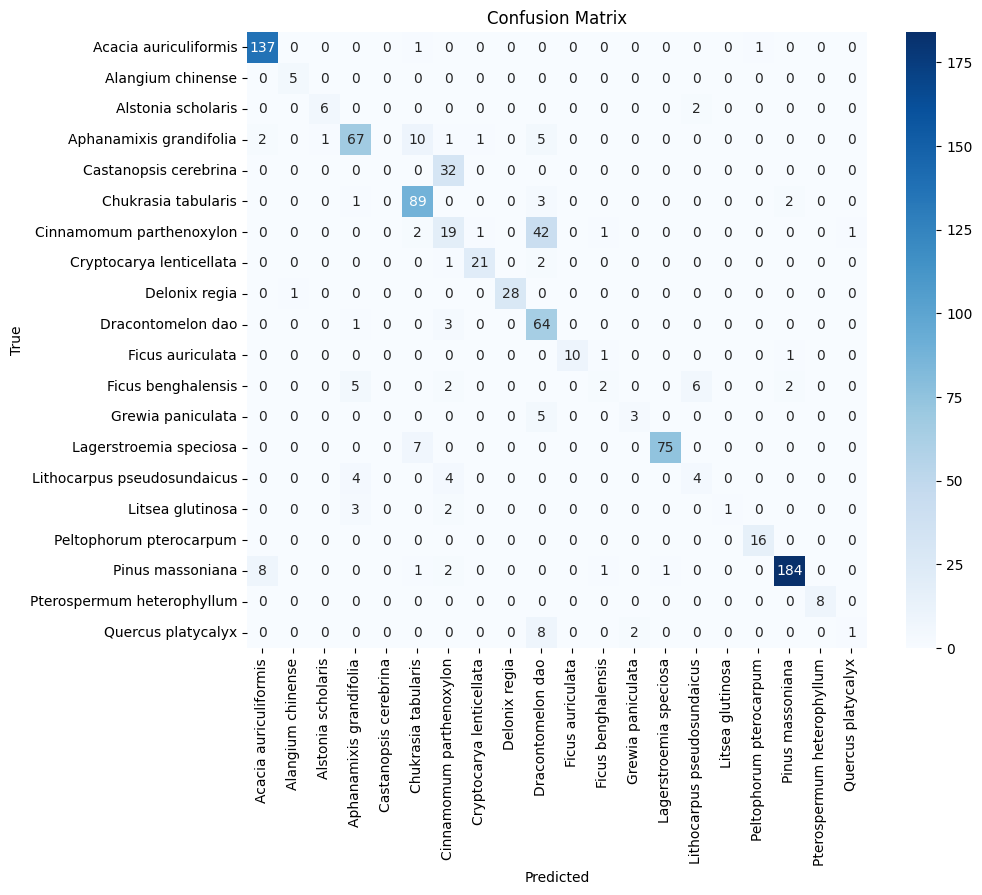


─────────────────────────────────────────
Classification Report
─────────────────────────────────────────
                             precision    recall  f1-score   support

      Acacia auriculiformis     0.9320    0.9856    0.9580       139
          Alangium chinense     0.8333    1.0000    0.9091         5
         Alstonia scholaris     0.8571    0.7500    0.8000         8
    Aphanamixis grandifolia     0.8272    0.7701    0.7976        87
      Castanopsis cerebrina     0.0000    0.0000    0.0000        32
        Chukrasia tabularis     0.8091    0.9368    0.8683        95
   Cinnamomum parthenoxylon     0.2879    0.2879    0.2879        66
   Cryptocarya lenticellata     0.9130    0.8750    0.8936        24
              Delonix regia     1.0000    0.9655    0.9825        29
          Dracontomelon dao     0.4961    0.9412    0.6497        68
           Ficus auriculata     1.0000    0.8333    0.9091        12
         Ficus benghalensis     0.4000    0.1176    0.1818      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [41]:
TEST_DIR   = "/content/VNUF-24082024-154-full/test" # Dedicated test set
test_dataset   = datasets.ImageFolder(TEST_DIR,   transform=val_transform)
test_loader   = DataLoader(test_dataset,   batch_size=32, shuffle=False,
                           num_workers=4, pin_memory=True)
print(f"Số mẫu test: {len(test_dataset)}")
# ─────────────────────────────────────────
# 8. FINAL EVALUATION ON TEST SET
# ─────────────────────────────────────────
print("\n─────────────────────────────────────────")
print("8. FINAL EVALUATION ON TEST SET")
print("─────────────────────────────────────────")

# Khởi tạo mô hình mới để tải trọng số
# Đảm bảo NUM_CLASSES, DEVICE đã được định nghĩa từ các cell trước
model_test = ModelCoral(num_classes=NUM_CLASSES).to(DEVICE)

# Load the best model
best_model_path = "/content/drive/MyDrive/cvbmc/model_chkpoint/1904/NONE_VNUF154_21species_best_vit_base_patch16_224.pth"
checkpoint = torch.load(best_model_path, map_location=DEVICE)
model_test.load_state_dict(checkpoint["model"])
print(f"Loaded best model from epoch {checkpoint['epoch']} with val_acc={checkpoint['val_acc']*100:.2f}%")

# Evaluate on test set
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate_and_predict(model_to_eval, loader: DataLoader):
    model_to_eval.eval()
    all_preds = []
    all_labels = []
    all_logits = []

    correct_top1 = 0
    correct_top3 = 0
    correct_top5 = 0
    n = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model_to_eval(imgs)

        # Top-1
        preds = logits.argmax(1)
        correct_top1 += (preds == labels).sum().item()

        # Top-3
        top3 = logits.topk(3, dim=1).indices  # shape: (batch_size, 5)
        correct_top3 += (top3 == labels.unsqueeze(1)).any(dim=1).sum().item()

        # Top-5
        top5 = logits.topk(5, dim=1).indices  # shape: (batch_size, 5)
        correct_top5 += (top5 == labels.unsqueeze(1)).any(dim=1).sum().item()

        n += imgs.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_logits.append(logits.cpu().numpy())

    return {
        "acc_top1": correct_top1 / n,
        "acc_top3": correct_top3 / n,
        "acc_top5": correct_top5 / n,
        "predictions": all_preds,
        "labels": all_labels,
        "logits": np.concatenate(all_logits)
    }

test_results = evaluate_and_predict(model_test, test_loader)
test_acc_top1 = test_results["acc_top1"]
test_acc_top3 = test_results["acc_top3"]
test_acc_top5 = test_results["acc_top5"]

print(f"Top-1 Accuracy: {test_acc_top1*100:.2f}%")
print(f"Top-3 Accuracy: {test_acc_top3*100:.2f}%")
print(f"Top-5 Accuracy: {test_acc_top5*100:.2f}%")

test_acc_top1 = test_results["acc_top1"]
test_acc_top3 = test_results["acc_top3"]
test_acc_top5 = test_results["acc_top5"]
all_preds = test_results["predictions"]
all_labels = test_results["labels"]
all_logits = test_results["logits"]

# Generate Confusion Matrix
print("\n─────────────────────────────────────────")
print("Confusion Matrix")
print("─────────────────────────────────────────")
cm = confusion_matrix(all_labels, all_preds)
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Generate Classification Report
print("\n─────────────────────────────────────────")
print("Classification Report")
print("─────────────────────────────────────────")
report = classification_report(all_labels, all_preds, target_names=test_dataset.classes, digits=4)
print(report)


📊 Confusion matrix saved to confusion_matrix.png


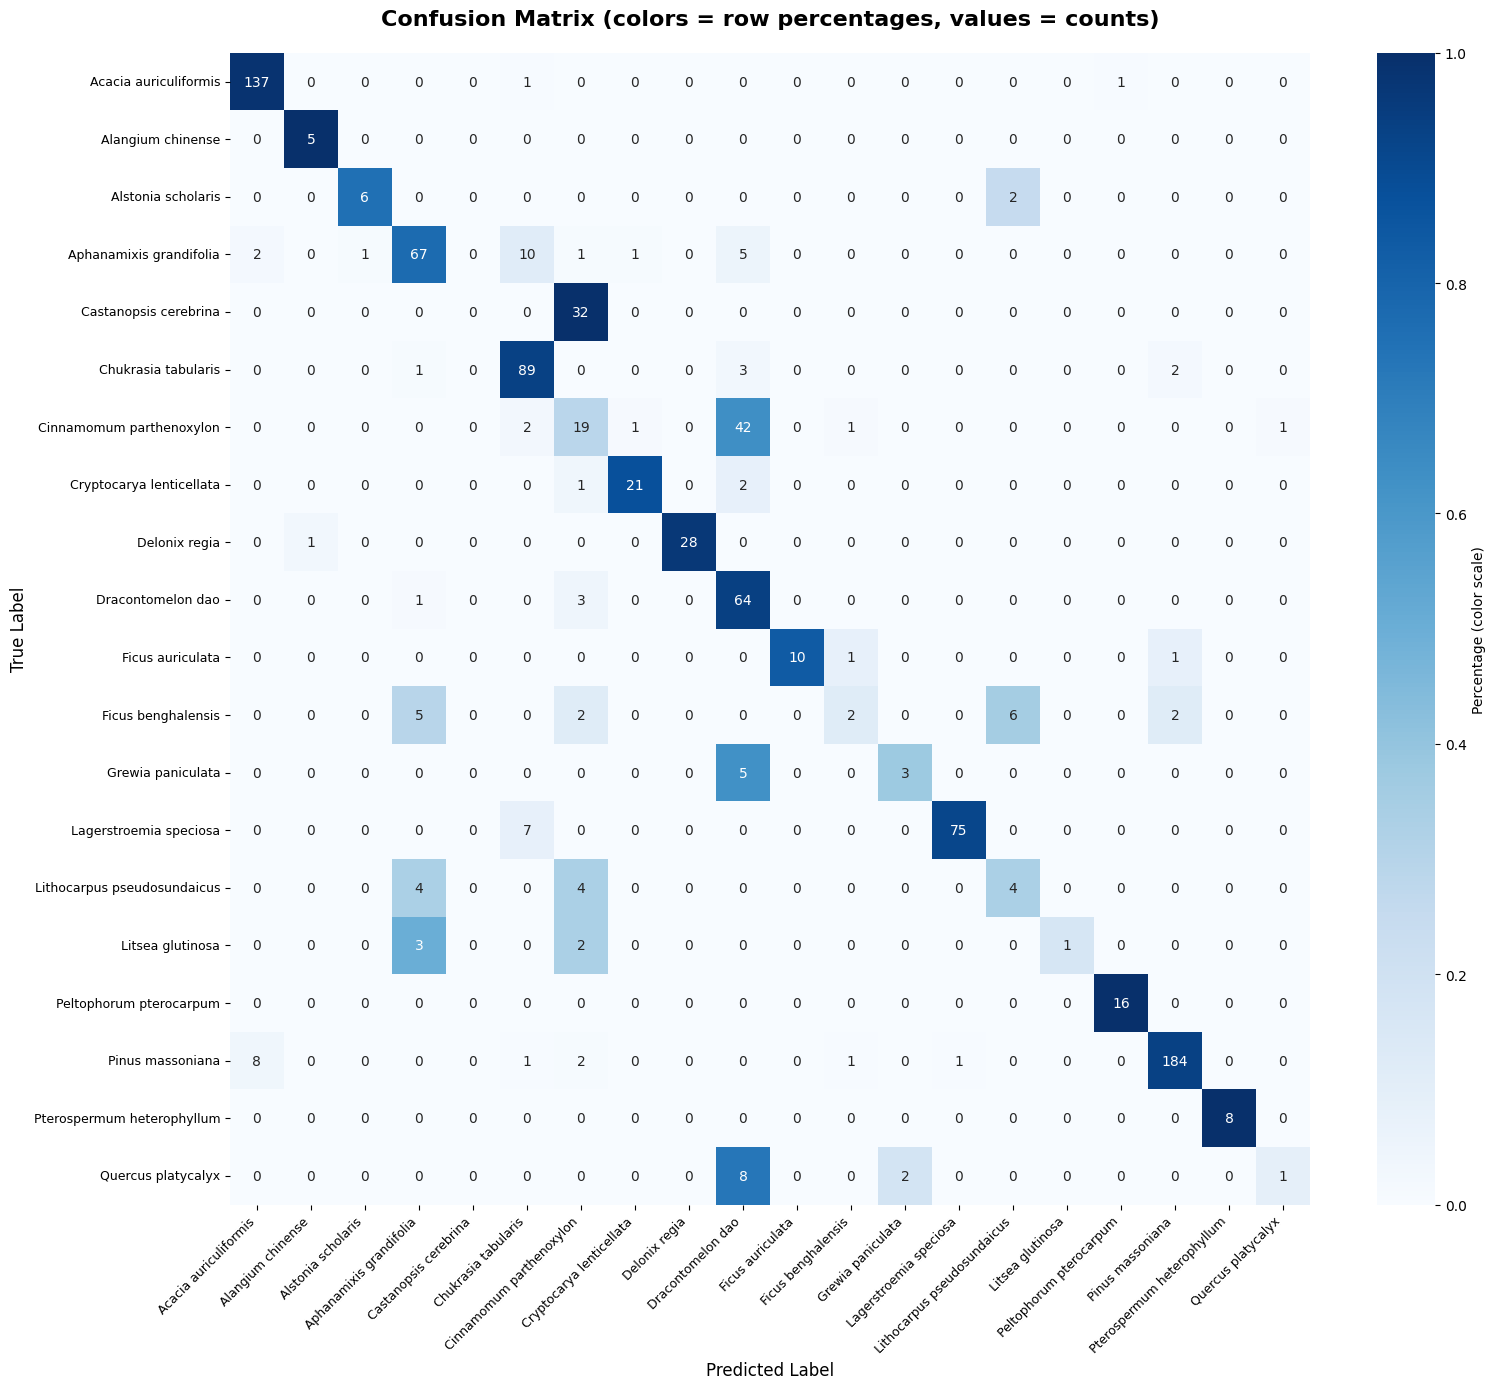

In [42]:
def plot_confusion_matrix(test_labels, test_predicted, class_names,
                         save_path='confusion_matrix.png',
                         scientific_names=None, normalize_per_row=True):
    """Plot confusion matrix with smart color normalization

    Args:
        test_labels: True labels
        test_predicted: Predicted labels
        class_names: Original class names (folder names)
        save_path: Path to save the plot
        scientific_names: List of scientific names to display (if None, use class_names)
        normalize_per_row: If True, normalize colors by row percentage (better for imbalanced data)
    """
    cm = confusion_matrix(test_labels, test_predicted)

    # Use scientific names if provided, otherwise use original class names
    display_names = scientific_names if scientific_names is not None else class_names

    # Create figure
    fig, ax = plt.subplots(figsize=(16, 14))

    if normalize_per_row:
        # Calculate percentage for each row (for coloring only)
        cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm_percent = np.nan_to_num(cm_percent)  # Handle division by zero

        # Use percentage values for coloring (0-1 scale)
        # But annotate with actual counts
        sns.heatmap(cm_percent,
                    annot=cm,  # Show counts
                    fmt='d',   # Integer format
                    cmap='Blues',
                    xticklabels=display_names,
                    yticklabels=display_names,
                    cbar_kws={'label': 'Percentage (color scale)'},
                    vmin=0,
                    vmax=1,
                    ax=ax)

        title = 'Confusion Matrix (colors = row percentages, values = counts)'
    else:
        # Standard confusion matrix without normalization
        sns.heatmap(cm,
                    annot=True,
                    fmt='d',
                    cmap='Blues',
                    xticklabels=display_names,
                    yticklabels=display_names,
                    cbar_kws={'label': 'Count'},
                    ax=ax)

        title = 'Confusion Matrix (Counts)'

    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📊 Confusion matrix saved to {save_path}")
    plt.show()


# Call the plot_confusion_matrix function
plot_confusion_matrix(all_labels, all_preds, test_dataset.classes)

Số mẫu test: 5700

─────────────────────────────────────────
8. FINAL EVALUATION ON TEST SET
─────────────────────────────────────────
Loaded best model from epoch 17 with val_acc=82.09%
Top-1 Accuracy: 85.42%
Top-3 Accuracy: 96.00%
Top-5 Accuracy: 97.96%

─────────────────────────────────────────
Confusion Matrix
─────────────────────────────────────────
[[1239    0    0    4    0    3    6    0    1    7    0    0    0    0
     0    0    0    2    0    0]
 [   0    1    0    1    0    2    0    0    0    0    0    0    0    0
     0    1    0    0    0    0]
 [   9    0    6    4    0    0    9    0    0   12    0    0    0    0
     1    0    0    0    0    0]
 [   1    0    0  653    1    4    9    3    1    6    0    0    0    0
     0    2    0    0    0    0]
 [   0    0    0   19   12    1    0    5    0    0    0    0    0    0
     2    1    0    1    0    0]
 [   0    0    0   11    0  485    2    0    0    6    0    0    0    1
     0    0    0    2    0    0]
 [   2    0 

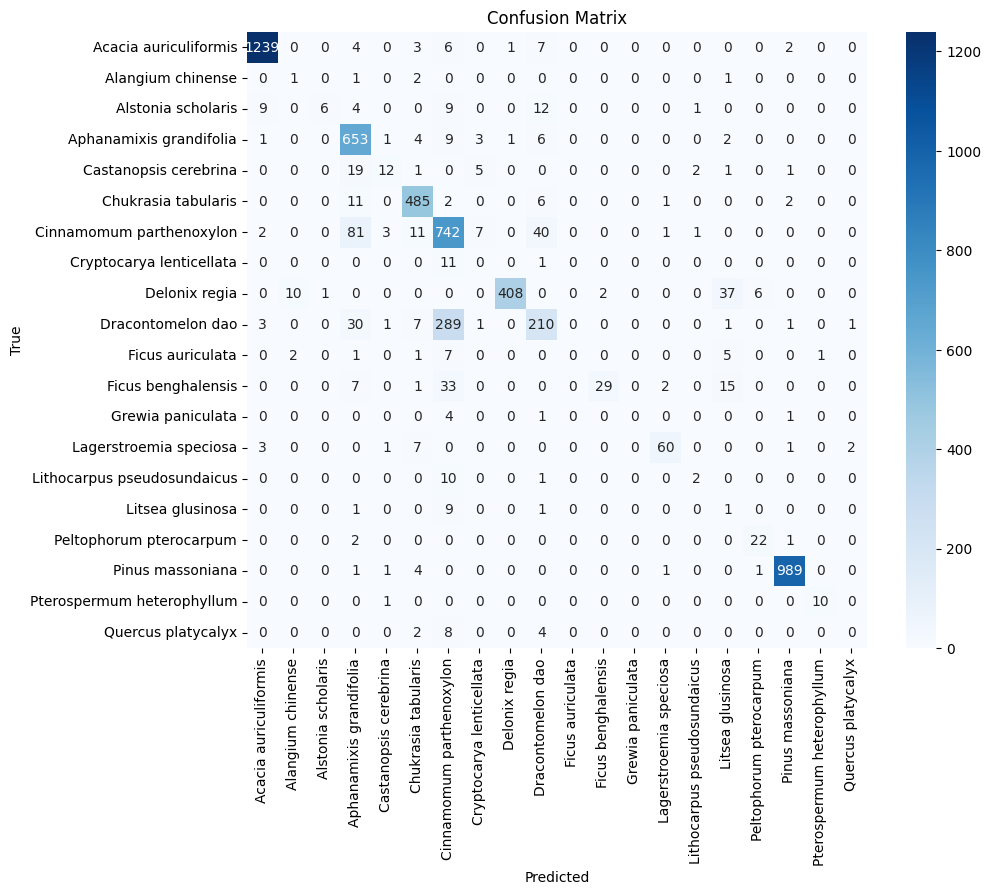


─────────────────────────────────────────
Classification Report
─────────────────────────────────────────
                             precision    recall  f1-score   support

      Acacia auriculiformis     0.9857    0.9818    0.9837      1262
          Alangium chinense     0.0769    0.2000    0.1111         5
         Alstonia scholaris     0.8571    0.1463    0.2500        41
    Aphanamixis grandifolia     0.8012    0.9603    0.8736       680
      Castanopsis cerebrina     0.6000    0.2927    0.3934        41
        Chukrasia tabularis     0.9186    0.9566    0.9372       507
   Cinnamomum parthenoxylon     0.6514    0.8356    0.7321       888
   Cryptocarya lenticellata     0.0000    0.0000    0.0000        12
              Delonix regia     0.9951    0.8793    0.9336       464
          Dracontomelon dao     0.7266    0.3860    0.5042       544
           Ficus auriculata     0.0000    0.0000    0.0000        17
         Ficus benghalensis     0.9355    0.3333    0.4915      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [43]:
TEST_DIR   = "/content/VNUF-24082024-299-mix" # Dedicated test set
test_dataset   = datasets.ImageFolder(TEST_DIR,   transform=val_transform)
test_loader   = DataLoader(test_dataset,   batch_size=32, shuffle=False,
                           num_workers=4, pin_memory=True)
print(f"Số mẫu test: {len(test_dataset)}")
# ─────────────────────────────────────────
# 8. FINAL EVALUATION ON TEST SET
# ─────────────────────────────────────────
print("\n─────────────────────────────────────────")
print("8. FINAL EVALUATION ON TEST SET")
print("─────────────────────────────────────────")

# Khởi tạo mô hình mới để tải trọng số
# Đảm bảo NUM_CLASSES, DEVICE đã được định nghĩa từ các cell trước
model_test = ModelCoral(num_classes=NUM_CLASSES).to(DEVICE)

# Load the best model
best_model_path = "/content/drive/MyDrive/cvbmc/model_chkpoint/1904/NONE_VNUF154_21species_best_vit_base_patch16_224.pth"
checkpoint = torch.load(best_model_path, map_location=DEVICE)
model_test.load_state_dict(checkpoint["model"])
print(f"Loaded best model from epoch {checkpoint['epoch']} with val_acc={checkpoint['val_acc']*100:.2f}%")

# Evaluate on test set
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate_and_predict(model_to_eval, loader: DataLoader):
    model_to_eval.eval()
    all_preds = []
    all_labels = []
    all_logits = []

    correct_top1 = 0
    correct_top3 = 0
    correct_top5 = 0
    n = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model_to_eval(imgs)

        # Top-1
        preds = logits.argmax(1)
        correct_top1 += (preds == labels).sum().item()

        # Top-3
        top3 = logits.topk(3, dim=1).indices  # shape: (batch_size, 5)
        correct_top3 += (top3 == labels.unsqueeze(1)).any(dim=1).sum().item()

        # Top-5
        top5 = logits.topk(5, dim=1).indices  # shape: (batch_size, 5)
        correct_top5 += (top5 == labels.unsqueeze(1)).any(dim=1).sum().item()

        n += imgs.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_logits.append(logits.cpu().numpy())

    return {
        "acc_top1": correct_top1 / n,
        "acc_top3": correct_top3 / n,
        "acc_top5": correct_top5 / n,
        "predictions": all_preds,
        "labels": all_labels,
        "logits": np.concatenate(all_logits)
    }

test_results = evaluate_and_predict(model_test, test_loader)
test_acc_top1 = test_results["acc_top1"]
test_acc_top3 = test_results["acc_top3"]
test_acc_top5 = test_results["acc_top5"]

print(f"Top-1 Accuracy: {test_acc_top1*100:.2f}%")
print(f"Top-3 Accuracy: {test_acc_top3*100:.2f}%")
print(f"Top-5 Accuracy: {test_acc_top5*100:.2f}%")

test_acc_top1 = test_results["acc_top1"]
test_acc_top3 = test_results["acc_top3"]
test_acc_top5 = test_results["acc_top5"]
all_preds = test_results["predictions"]
all_labels = test_results["labels"]
all_logits = test_results["logits"]

# Generate Confusion Matrix
print("\n─────────────────────────────────────────")
print("Confusion Matrix")
print("─────────────────────────────────────────")
cm = confusion_matrix(all_labels, all_preds)
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Generate Classification Report
print("\n─────────────────────────────────────────")
print("Classification Report")
print("─────────────────────────────────────────")
report = classification_report(all_labels, all_preds, target_names=test_dataset.classes, digits=4)
print(report)


Số mẫu test: 111

─────────────────────────────────────────
8. FINAL EVALUATION ON TEST SET
─────────────────────────────────────────
Loaded best model from epoch 17 with val_acc=82.09%
Top-1 Accuracy: 28.83%
Top-3 Accuracy: 54.95%
Top-5 Accuracy: 74.77%

─────────────────────────────────────────
Confusion Matrix
─────────────────────────────────────────
[[5 0 0 4 2 0 3 0 0 2 0 0 0 0 0 0 6 1 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 8 0 8 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0]
 [0 0 0 4 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 2 0 4 0 0 0 5 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 3 0 1 0 0 0 4 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0

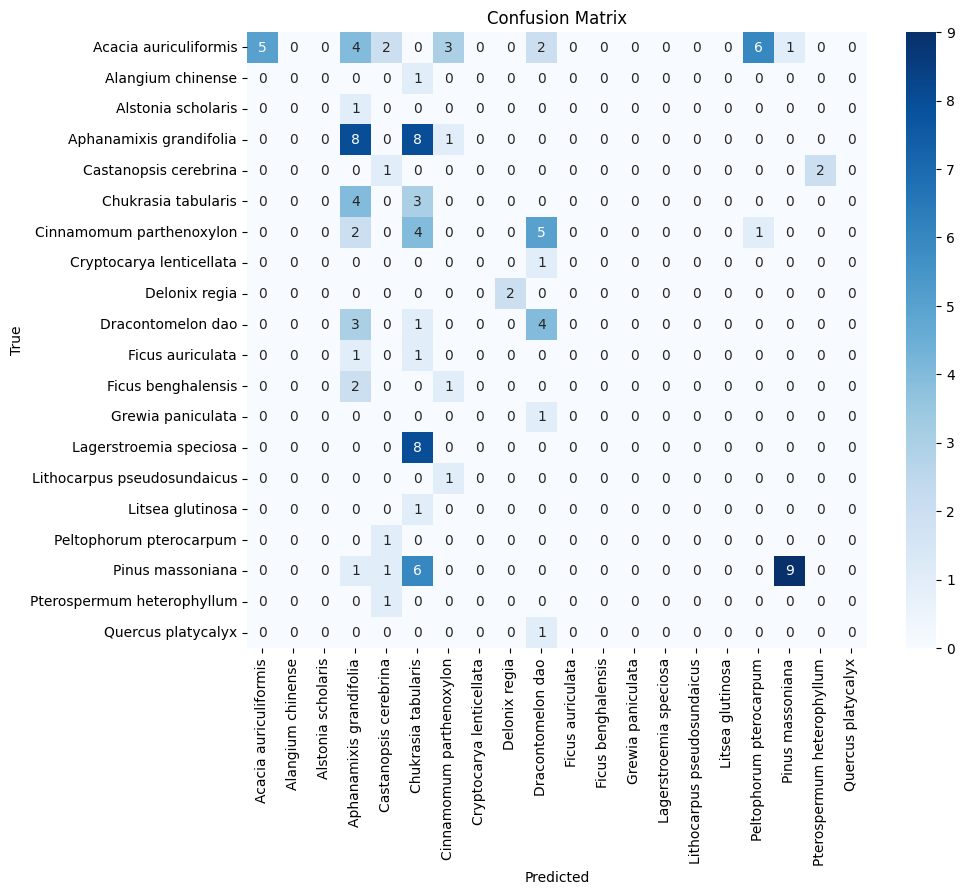


─────────────────────────────────────────
Classification Report
─────────────────────────────────────────
                             precision    recall  f1-score   support

      Acacia auriculiformis     1.0000    0.2174    0.3571        23
          Alangium chinense     0.0000    0.0000    0.0000         1
         Alstonia scholaris     0.0000    0.0000    0.0000         1
    Aphanamixis grandifolia     0.3077    0.4706    0.3721        17
      Castanopsis cerebrina     0.1667    0.3333    0.2222         3
        Chukrasia tabularis     0.0909    0.4286    0.1500         7
   Cinnamomum parthenoxylon     0.0000    0.0000    0.0000        12
   Cryptocarya lenticellata     0.0000    0.0000    0.0000         1
              Delonix regia     1.0000    1.0000    1.0000         2
          Dracontomelon dao     0.2857    0.5000    0.3636         8
           Ficus auriculata     0.0000    0.0000    0.0000         2
         Ficus benghalensis     0.0000    0.0000    0.0000      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [44]:
TEST_DIR   = "/content/VNUF-10082024-234-full/test" # Dedicated test set
test_dataset   = datasets.ImageFolder(TEST_DIR,   transform=val_transform)
test_loader   = DataLoader(test_dataset,   batch_size=32, shuffle=False,
                           num_workers=4, pin_memory=True)
print(f"Số mẫu test: {len(test_dataset)}")
# ─────────────────────────────────────────
# 8. FINAL EVALUATION ON TEST SET
# ─────────────────────────────────────────
print("\n─────────────────────────────────────────")
print("8. FINAL EVALUATION ON TEST SET")
print("─────────────────────────────────────────")

# Khởi tạo mô hình mới để tải trọng số
# Đảm bảo NUM_CLASSES, DEVICE đã được định nghĩa từ các cell trước
model_test = ModelCoral(num_classes=NUM_CLASSES).to(DEVICE)

# Load the best model
best_model_path = "/content/drive/MyDrive/cvbmc/model_chkpoint/1904/NONE_VNUF154_21species_best_vit_base_patch16_224.pth"
checkpoint = torch.load(best_model_path, map_location=DEVICE)
model_test.load_state_dict(checkpoint["model"])
print(f"Loaded best model from epoch {checkpoint['epoch']} with val_acc={checkpoint['val_acc']*100:.2f}%")

# Evaluate on test set
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate_and_predict(model_to_eval, loader: DataLoader):
    model_to_eval.eval()
    all_preds = []
    all_labels = []
    all_logits = []

    correct_top1 = 0
    correct_top3 = 0
    correct_top5 = 0
    n = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model_to_eval(imgs)

        # Top-1
        preds = logits.argmax(1)
        correct_top1 += (preds == labels).sum().item()

        # Top-3
        top3 = logits.topk(3, dim=1).indices  # shape: (batch_size, 5)
        correct_top3 += (top3 == labels.unsqueeze(1)).any(dim=1).sum().item()

        # Top-5
        top5 = logits.topk(5, dim=1).indices  # shape: (batch_size, 5)
        correct_top5 += (top5 == labels.unsqueeze(1)).any(dim=1).sum().item()

        n += imgs.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_logits.append(logits.cpu().numpy())

    return {
        "acc_top1": correct_top1 / n,
        "acc_top3": correct_top3 / n,
        "acc_top5": correct_top5 / n,
        "predictions": all_preds,
        "labels": all_labels,
        "logits": np.concatenate(all_logits)
    }

test_results = evaluate_and_predict(model_test, test_loader)
test_acc_top1 = test_results["acc_top1"]
test_acc_top3 = test_results["acc_top3"]
test_acc_top5 = test_results["acc_top5"]

print(f"Top-1 Accuracy: {test_acc_top1*100:.2f}%")
print(f"Top-3 Accuracy: {test_acc_top3*100:.2f}%")
print(f"Top-5 Accuracy: {test_acc_top5*100:.2f}%")

test_acc_top1 = test_results["acc_top1"]
test_acc_top3 = test_results["acc_top3"]
test_acc_top5 = test_results["acc_top5"]
all_preds = test_results["predictions"]
all_labels = test_results["labels"]
all_logits = test_results["logits"]

# Generate Confusion Matrix
print("\n─────────────────────────────────────────")
print("Confusion Matrix")
print("─────────────────────────────────────────")
cm = confusion_matrix(all_labels, all_preds)
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Generate Classification Report
print("\n─────────────────────────────────────────")
print("Classification Report")
print("─────────────────────────────────────────")
report = classification_report(all_labels, all_preds, target_names=test_dataset.classes, digits=4)
print(report)


Số mẫu test: 529

─────────────────────────────────────────
8. FINAL EVALUATION ON TEST SET
─────────────────────────────────────────
Loaded best model from epoch 17 with val_acc=82.09%
Top-1 Accuracy: 45.75%
Top-3 Accuracy: 73.16%
Top-5 Accuracy: 83.55%

─────────────────────────────────────────
Confusion Matrix
─────────────────────────────────────────
[[121   0   0  11   3   0   4   0   1  25   0   0   0   0   0   0   1   4
    0   0]
 [  0   0   0   0   0   0   0   0   0   3   0   0   0   0   0   0   0   0
    0   0]
 [  0   0   0   0   0   0   0   0   0   2   0   0   0   1   0   0   1   0
    0   0]
 [  0   0   0  43   0   1   2   1   0  11   0   0   0   0   0   0   6   1
    0   0]
 [  0   0   0   0   0   0   1   0   0   2   0   0   0   0   0   0   0   0
    0   0]
 [  0   0   0   2   0  12   2   0   0   6   0   0   0   0   0   0   0   1
    0   0]
 [  9   0   0   9   2   0  23   0   0  32   0   0   0   0   0   0   0   0
    0   0]
 [  1   0   0   0   0   0   0   0   0   0   0   

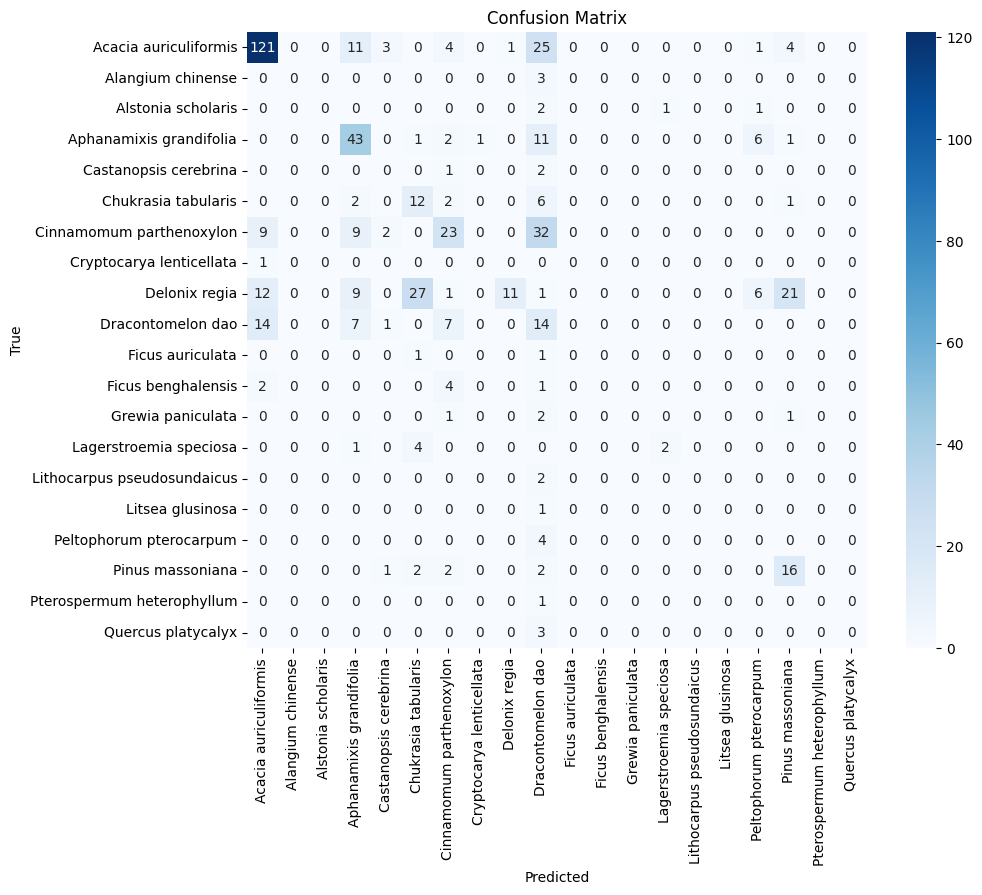


─────────────────────────────────────────
Classification Report
─────────────────────────────────────────
                             precision    recall  f1-score   support

      Acacia auriculiformis     0.7610    0.7118    0.7356       170
          Alangium chinense     0.0000    0.0000    0.0000         3
         Alstonia scholaris     0.0000    0.0000    0.0000         4
    Aphanamixis grandifolia     0.5244    0.6615    0.5850        65
      Castanopsis cerebrina     0.0000    0.0000    0.0000         3
        Chukrasia tabularis     0.2553    0.5217    0.3429        23
   Cinnamomum parthenoxylon     0.4894    0.3067    0.3770        75
   Cryptocarya lenticellata     0.0000    0.0000    0.0000         1
              Delonix regia     0.9167    0.1250    0.2200        88
          Dracontomelon dao     0.1239    0.3256    0.1795        43
           Ficus auriculata     0.0000    0.0000    0.0000         2
         Ficus benghalensis     0.0000    0.0000    0.0000      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [45]:
TEST_DIR   = "/content/VNUF-22052024-134-mix" # Dedicated test set
test_dataset   = datasets.ImageFolder(TEST_DIR,   transform=val_transform)
test_loader   = DataLoader(test_dataset,   batch_size=32, shuffle=False,
                           num_workers=4, pin_memory=True)
print(f"Số mẫu test: {len(test_dataset)}")
# ─────────────────────────────────────────
# 8. FINAL EVALUATION ON TEST SET
# ─────────────────────────────────────────
print("\n─────────────────────────────────────────")
print("8. FINAL EVALUATION ON TEST SET")
print("─────────────────────────────────────────")

# Khởi tạo mô hình mới để tải trọng số
# Đảm bảo NUM_CLASSES, DEVICE đã được định nghĩa từ các cell trước
model_test = ModelCoral(num_classes=NUM_CLASSES).to(DEVICE)

# Load the best model
best_model_path = "/content/drive/MyDrive/cvbmc/model_chkpoint/1904/NONE_VNUF154_21species_best_vit_base_patch16_224.pth"
checkpoint = torch.load(best_model_path, map_location=DEVICE)
model_test.load_state_dict(checkpoint["model"])
print(f"Loaded best model from epoch {checkpoint['epoch']} with val_acc={checkpoint['val_acc']*100:.2f}%")

# Evaluate on test set
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate_and_predict(model_to_eval, loader: DataLoader):
    model_to_eval.eval()
    all_preds = []
    all_labels = []
    all_logits = []

    correct_top1 = 0
    correct_top3 = 0
    correct_top5 = 0
    n = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model_to_eval(imgs)

        # Top-1
        preds = logits.argmax(1)
        correct_top1 += (preds == labels).sum().item()

        # Top-3
        top3 = logits.topk(3, dim=1).indices  # shape: (batch_size, 5)
        correct_top3 += (top3 == labels.unsqueeze(1)).any(dim=1).sum().item()

        # Top-5
        top5 = logits.topk(5, dim=1).indices  # shape: (batch_size, 5)
        correct_top5 += (top5 == labels.unsqueeze(1)).any(dim=1).sum().item()

        n += imgs.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_logits.append(logits.cpu().numpy())

    return {
        "acc_top1": correct_top1 / n,
        "acc_top3": correct_top3 / n,
        "acc_top5": correct_top5 / n,
        "predictions": all_preds,
        "labels": all_labels,
        "logits": np.concatenate(all_logits)
    }

test_results = evaluate_and_predict(model_test, test_loader)
test_acc_top1 = test_results["acc_top1"]
test_acc_top3 = test_results["acc_top3"]
test_acc_top5 = test_results["acc_top5"]

print(f"Top-1 Accuracy: {test_acc_top1*100:.2f}%")
print(f"Top-3 Accuracy: {test_acc_top3*100:.2f}%")
print(f"Top-5 Accuracy: {test_acc_top5*100:.2f}%")

test_acc_top1 = test_results["acc_top1"]
test_acc_top3 = test_results["acc_top3"]
test_acc_top5 = test_results["acc_top5"]
all_preds = test_results["predictions"]
all_labels = test_results["labels"]
all_logits = test_results["logits"]

# Generate Confusion Matrix
print("\n─────────────────────────────────────────")
print("Confusion Matrix")
print("─────────────────────────────────────────")
cm = confusion_matrix(all_labels, all_preds)
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Generate Classification Report
print("\n─────────────────────────────────────────")
print("Classification Report")
print("─────────────────────────────────────────")
report = classification_report(all_labels, all_preds, target_names=test_dataset.classes, digits=4)
print(report)



# Gọi model

In [ ]:
vit_models = timm.list_models('*patch16_dinov3*')
print(vit_models)

['vit_7b_patch16_dinov3', 'vit_base_patch16_dinov3', 'vit_base_patch16_dinov3_qkvb', 'vit_huge_plus_patch16_dinov3', 'vit_huge_plus_patch16_dinov3_qkvb', 'vit_large_patch16_dinov3', 'vit_large_patch16_dinov3_qkvb', 'vit_small_patch16_dinov3', 'vit_small_patch16_dinov3_qkvb', 'vit_small_plus_patch16_dinov3', 'vit_small_plus_patch16_dinov3_qkvb']
